<a href="https://colab.research.google.com/github/sayali-jatrate/project1/blob/main/polynomialDay5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, GridSearchCV,
                                       learning_curve, validation_curve)
from sklearn.preprocessing    import (StandardScaler, MinMaxScaler,
                                       LabelEncoder, PolynomialFeatures)
from sklearn.impute            import SimpleImputer
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.utils             import resample

# ── Models — Day 5 ───────────────────────────────────────────────────────────
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC

# ── Models — Day 6 ───────────────────────────────────────────────────────────
from sklearn.tree             import (DecisionTreeClassifier,
                                       export_text, plot_tree)
from sklearn.ensemble         import (RandomForestClassifier,
                                       GradientBoostingClassifier,
                                       VotingClassifier, BaggingClassifier)

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics          import (accuracy_score, f1_score,
                                       classification_report,
                                       confusion_matrix, roc_auc_score)
from sklearn.preprocessing    import label_binarize

# ── Feature selection ─────────────────────────────────────────────────────────
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.inspection        import permutation_importance

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
PALETTE = ['#4C72B0', '#55A868', '#C44E52']
SEED    = 42

print('✅ All libraries imported!')

✅ All libraries imported!


In [ ]:
from google.colab import files
upload =files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
df = pd.read_csv('Iris.csv').drop(columns=['Id'])
df['Species'] = df['Species'].str.replace('Iris-', '', regex=False)

ORIGINAL_FEATURES = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
TARGET = 'Species'

le = LabelEncoder()
df['label'] = le.fit_transform(df[TARGET])   # setosa=0, versicolor=1, virginica=2

print('Shape:', df.shape)
print('Class distribution:\n', df[TARGET].value_counts())
df.head(6)

Shape: (150, 6)
Class distribution:
 Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,label
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0
5,5.4,3.9,1.7,0.4,setosa,0


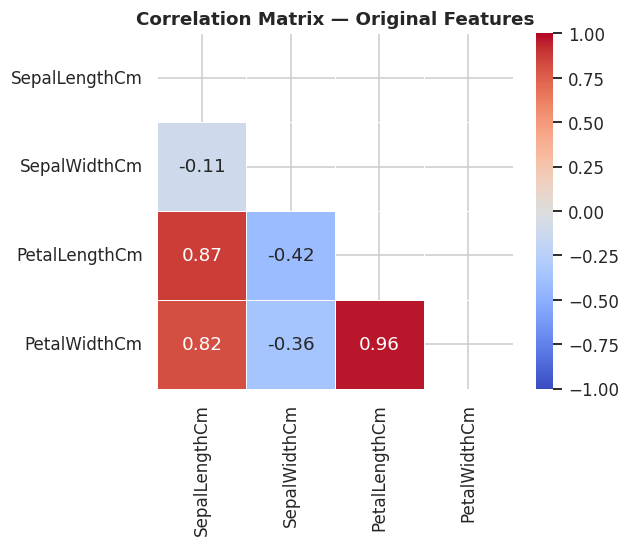

In [ ]:
plt.figure(figsize=(6, 5))
corr = df[ORIGINAL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Original Features', fontweight='bold')
plt.tight_layout()
plt.show()

# 💡 PetalLength & PetalWidth highly correlated → good candidate for ratio features

In [ ]:
# ── 2A: Domain-inspired feature creation ──────────────────────────────────────
df_feat = df.copy()

# --- Ratio features ---
df_feat['Sepal_Ratio']      = df_feat['SepalLengthCm'] / (df_feat['SepalWidthCm'] + 1e-6)
df_feat['Petal_Ratio']      = df_feat['PetalLengthCm'] / (df_feat['PetalWidthCm'] + 1e-6)

# --- Area approximations (ellipse: π × a × b) ---
df_feat['Sepal_Area']       = np.pi * df_feat['SepalLengthCm'] * df_feat['SepalWidthCm']
df_feat['Petal_Area']       = np.pi * df_feat['PetalLengthCm'] * df_feat['PetalWidthCm']

# --- Difference features ---
df_feat['Length_Diff']      = df_feat['SepalLengthCm'] - df_feat['PetalLengthCm']
df_feat['Width_Diff']       = df_feat['SepalWidthCm']  - df_feat['PetalWidthCm']

# --- Log transforms (reduce skewness) ---
df_feat['Log_PetalLength']  = np.log1p(df_feat['PetalLengthCm'])
df_feat['Log_PetalWidth']   = np.log1p(df_feat['PetalWidthCm'])

# --- Size score (sum of all lengths) ---
df_feat['Total_Size']       = (df_feat['SepalLengthCm'] + df_feat['SepalWidthCm'] +
                                df_feat['PetalLengthCm'] + df_feat['PetalWidthCm'])

NEW_FEATURES = ['Sepal_Ratio', 'Petal_Ratio', 'Sepal_Area', 'Petal_Area',
                'Length_Diff', 'Width_Diff', 'Log_PetalLength', 'Log_PetalWidth',
                'Total_Size']

print(f'Original features : {len(ORIGINAL_FEATURES)}')
print(f'Engineered features: {len(NEW_FEATURES)}')
print(f'Total features     : {len(ORIGINAL_FEATURES) + len(NEW_FEATURES)}')
df_feat[ORIGINAL_FEATURES + NEW_FEATURES].head(5).round(3)

Original features : 4
Engineered features: 9
Total features     : 13


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Sepal_Ratio,Petal_Ratio,Sepal_Area,Petal_Area,Length_Diff,Width_Diff,Log_PetalLength,Log_PetalWidth,Total_Size
0,5.1,3.5,1.4,0.2,1.457,7.0,56.077,0.880,3.7,3.3,0.875,0.182,10.2
1,4.9,3.0,1.4,0.2,1.633,7.0,46.181,0.880,3.5,2.8,0.875,0.182,9.5
2,4.7,3.2,1.3,0.2,1.469,6.5,47.250,0.817,3.4,3.0,0.833,0.182,9.4
3,4.6,3.1,1.5,0.2,1.484,7.5,44.799,0.942,3.1,2.9,0.916,0.182,9.4
4,5.0,3.6,1.4,0.2,1.389,7.0,56.549,0.880,3.6,3.4,0.875,0.182,10.2


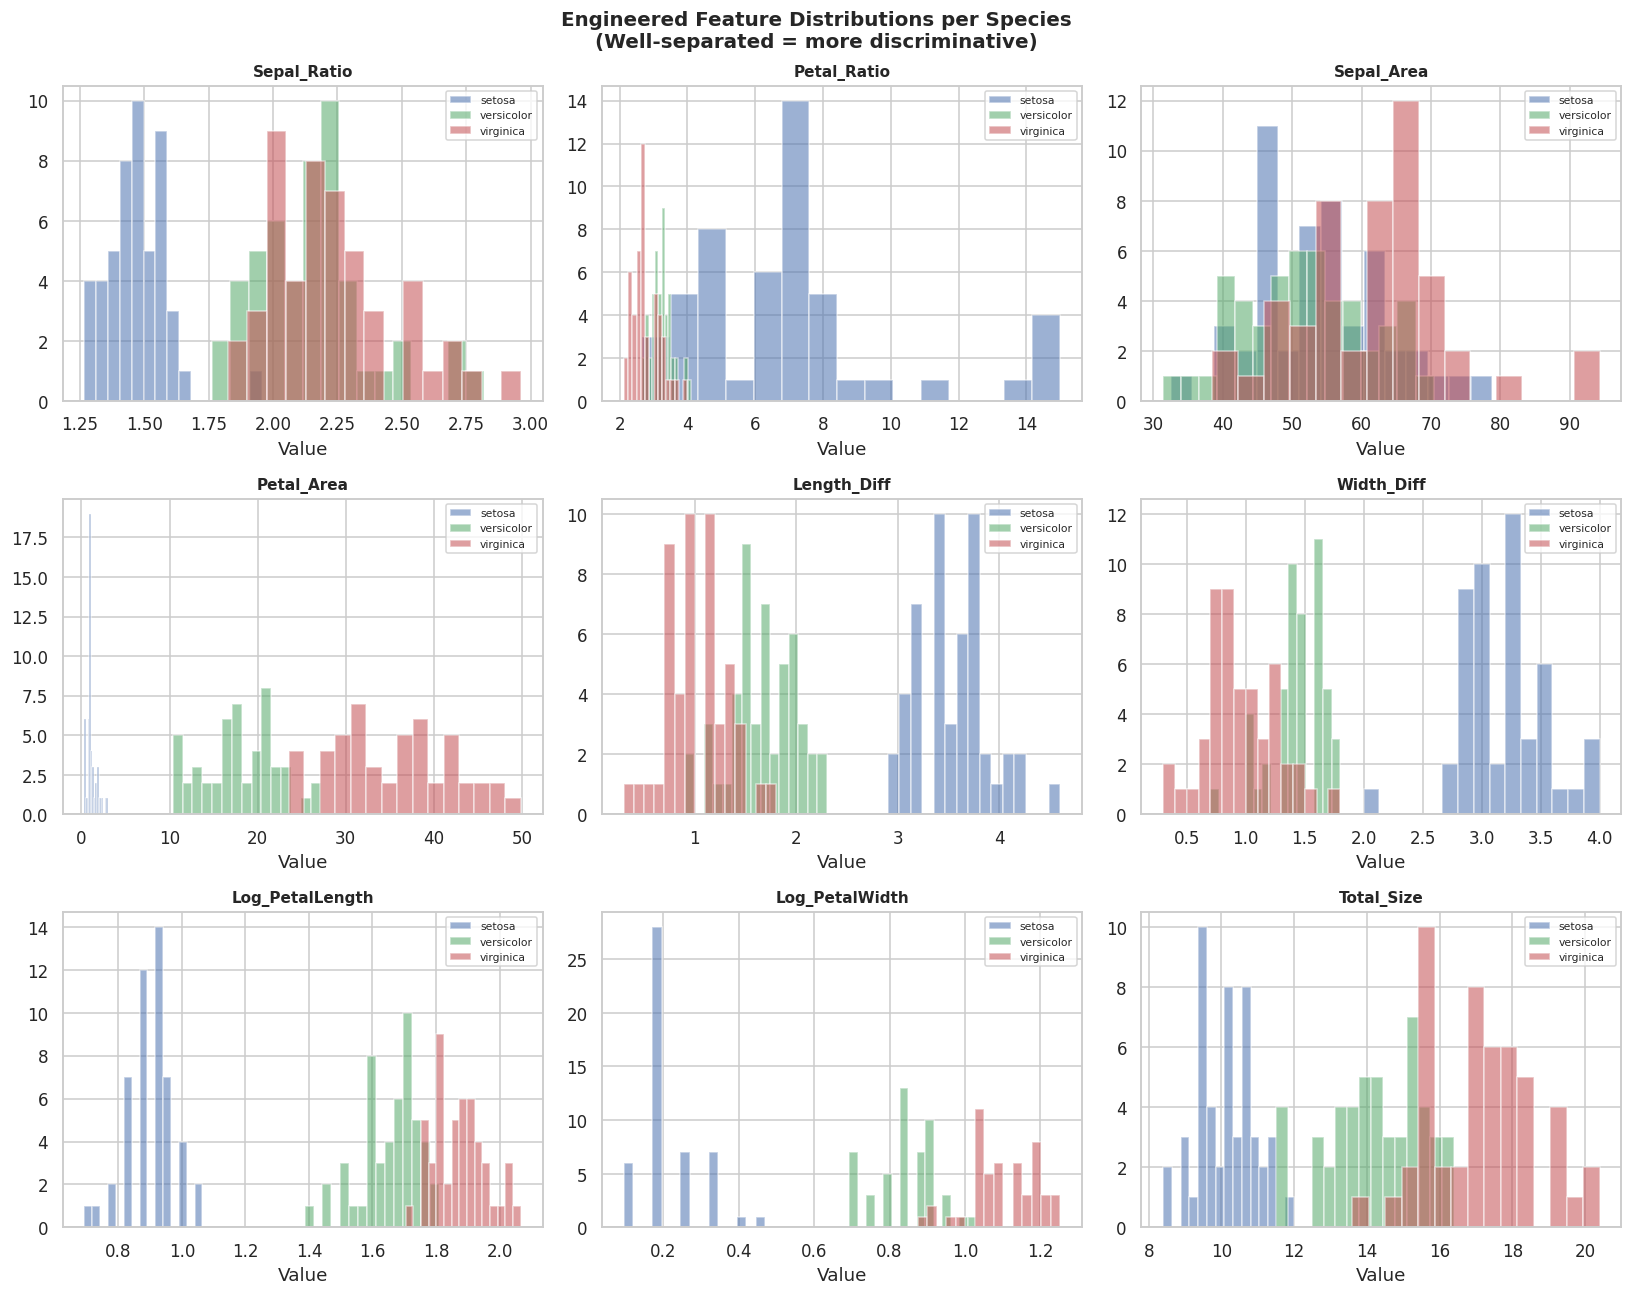

In [ ]:
# ── 2B: Visualise new features' discriminative power ─────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feat in zip(axes.flatten(), NEW_FEATURES):
    for species, color in zip(le.classes_, PALETTE):
        subset = df_feat[df_feat[TARGET] == species][feat]
        ax.hist(subset, bins=15, alpha=0.55, color=color,
                label=species, edgecolor='white')
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')
    ax.legend(fontsize=7)

plt.suptitle('Engineered Feature Distributions per Species\n'
             '(Well-separated = more discriminative)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 💡 Petal_Area and Petal_Ratio separate the 3 species very cleanly!

In [ ]:
# ── 2C: Polynomial Features (automated interaction terms) ─────────────────────
# degree=2: creates x1², x2², x1×x2 etc. — captures non-linear patterns

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(df[ORIGINAL_FEATURES])

poly_names = poly.get_feature_names_out(ORIGINAL_FEATURES)
print(f'Original features  : {len(ORIGINAL_FEATURES)}')
print(f'Polynomial features: {len(poly_names)}')
print('\nAll polynomial feature names:')
for i, name in enumerate(poly_names):
    print(f'  {i+1:2d}. {name}')

Original features  : 4
Polynomial features: 14

All polynomial feature names:
   1. SepalLengthCm
   2. SepalWidthCm
   3. PetalLengthCm
   4. PetalWidthCm
   5. SepalLengthCm^2
   6. SepalLengthCm SepalWidthCm
   7. SepalLengthCm PetalLengthCm
   8. SepalLengthCm PetalWidthCm
   9. SepalWidthCm^2
  10. SepalWidthCm PetalLengthCm
  11. SepalWidthCm PetalWidthCm
  12. PetalLengthCm^2
  13. PetalLengthCm PetalWidthCm
  14. PetalWidthCm^2


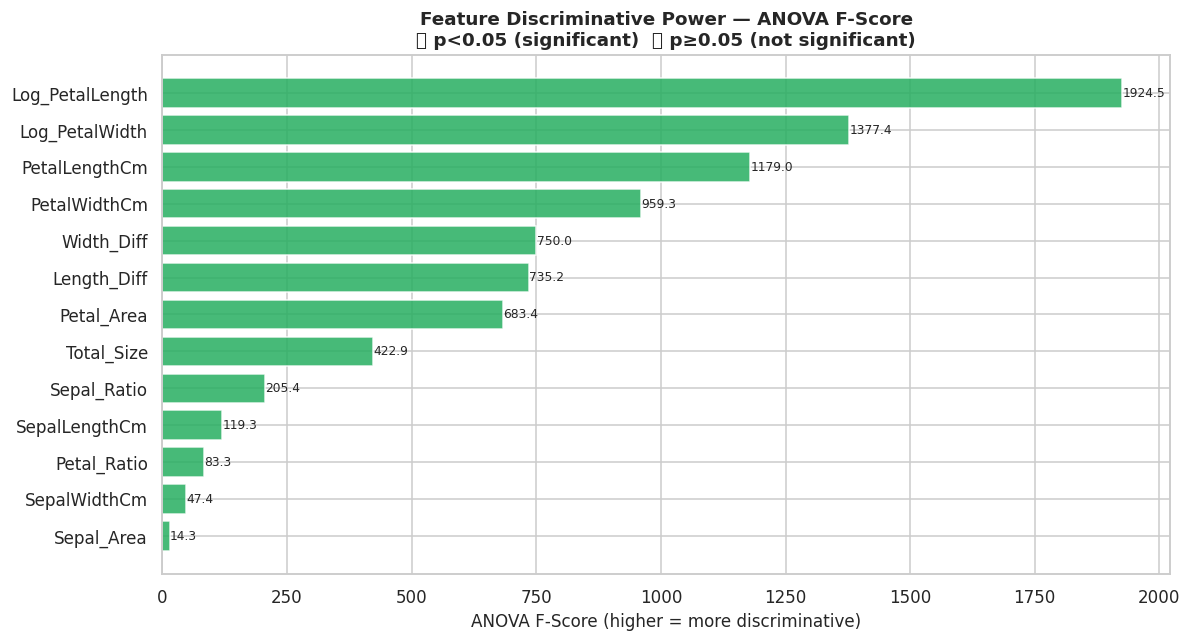


Top 5 most discriminative features:
        Feature  F-Score  p-value
Log_PetalLength  1924.51      0.0
 Log_PetalWidth  1377.37      0.0
  PetalLengthCm  1179.03      0.0
   PetalWidthCm   959.32      0.0
     Width_Diff   749.96      0.0


In [ ]:
# ── 2D: Feature importance via ANOVA F-test ───────────────────────────────────
# F-test: measures how much a feature varies between classes vs within classes
ALL_FEATURE_NAMES = ORIGINAL_FEATURES + NEW_FEATURES
X_all = df_feat[ALL_FEATURE_NAMES].values
y_all = df_feat['label'].values

f_scores, p_values = f_classif(X_all, y_all)

fi_df = pd.DataFrame({
    'Feature': ALL_FEATURE_NAMES,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values('F-Score', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(fi_df['Feature'][::-1], fi_df['F-Score'][::-1],
               color=['#27ae60' if p < 0.05 else '#e74c3c'
                      for p in fi_df['p-value'][::-1]],
               edgecolor='white', alpha=0.85)
ax.set_xlabel('ANOVA F-Score (higher = more discriminative)', fontsize=11)
ax.set_title('Feature Discriminative Power — ANOVA F-Score\n'
             '🟢 p<0.05 (significant)  🔴 p≥0.05 (not significant)',
             fontweight='bold')

for bar, v in zip(bars, fi_df['F-Score'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\nTop 5 most discriminative features:')
print(fi_df[['Feature', 'F-Score', 'p-value']].head(5).round(2).to_string(index=False))

In [ ]:
# ── 2E: Binning — discretize continuous features into categories ───────────────
# Useful when the relationship is threshold-based, not linear

df_feat['PetalLength_Bin'] = pd.cut(
    df_feat['PetalLengthCm'],
    bins=[0, 2, 4, 7],
    labels=['Short (<2cm)', 'Medium (2-4cm)', 'Long (>4cm)']
)

print('PetalLength binning distribution:')
print(pd.crosstab(df_feat['PetalLength_Bin'], df_feat[TARGET]))

# 💡 Short petals = only setosa, Long petals = mostly virginica
# This is essentially what decision trees learn automatically!

PetalLength binning distribution:
Species          setosa  versicolor  virginica
PetalLength_Bin                               
Short (<2cm)         50           0          0
Medium (2-4cm)        0          16          0
Long (>4cm)           0          34         50


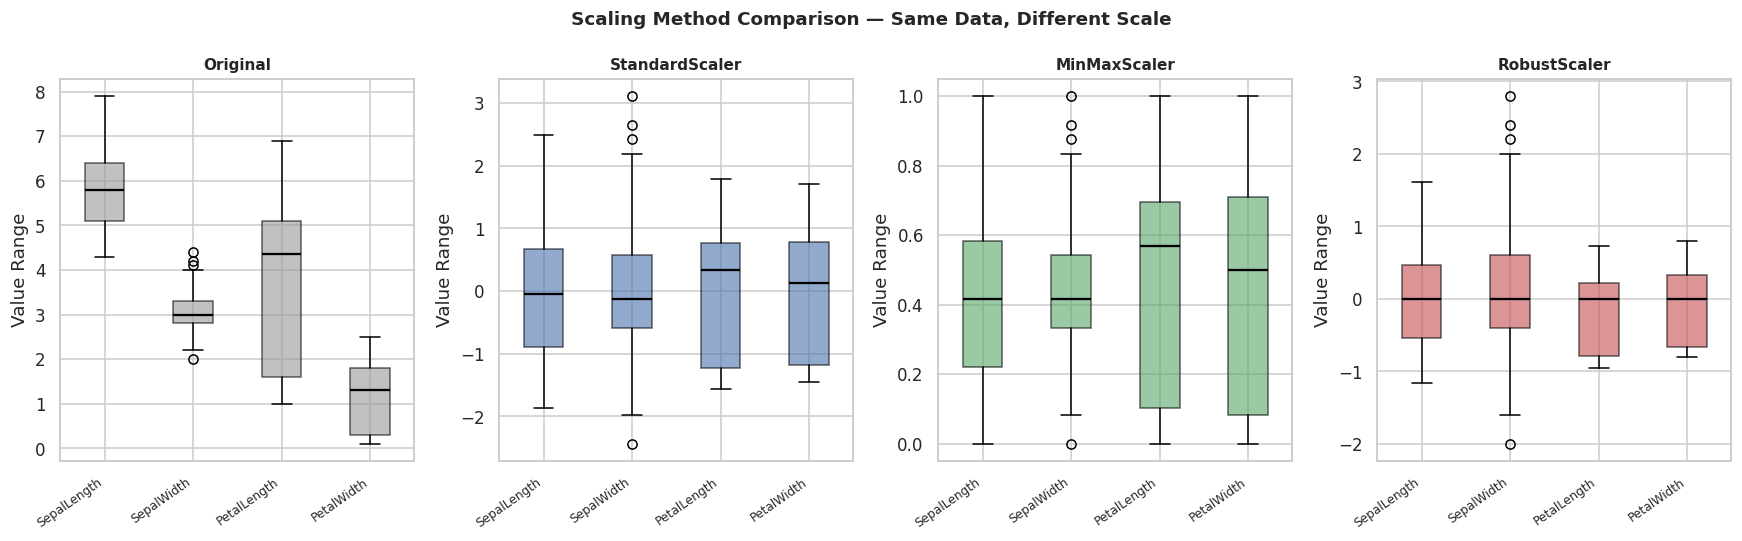

In [ ]:
# ── 3A: Compare StandardScaler vs MinMaxScaler vs RobustScaler ────────────────
from sklearn.preprocessing import RobustScaler

X_raw = df[ORIGINAL_FEATURES].values

scalers = {
    'Original':      X_raw,
    'StandardScaler': StandardScaler().fit_transform(X_raw),
    'MinMaxScaler':   MinMaxScaler().fit_transform(X_raw),
    'RobustScaler':   RobustScaler().fit_transform(X_raw),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
colors_s  = ['#999999', '#4C72B0', '#55A868', '#C44E52']

for ax, (name, Xs), color in zip(axes, scalers.items(), colors_s):
    ax.boxplot(Xs, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=1.5))
    ax.set_xticklabels([f.replace('Cm','') for f in ORIGINAL_FEATURES],
                       rotation=35, ha='right', fontsize=8)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_ylabel('Value Range')

plt.suptitle('Scaling Method Comparison — Same Data, Different Scale',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 3B: Impact of scaling on SVM accuracy ────────────────────────────────────
X = df[ORIGINAL_FEATURES]
y = df['label']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                            stratify=y, random_state=SEED)

scale_results = {}
for name, sc_class in [('No Scaling', None),
                        ('StandardScaler', StandardScaler()),
                        ('MinMaxScaler',   MinMaxScaler()),
                        ('RobustScaler',   RobustScaler())]:
    if sc_class:
        Xtr_s = sc_class.fit_transform(X_tr)
        Xte_s = sc_class.transform(X_te)
    else:
        Xtr_s, Xte_s = X_tr.values, X_te.values

    svm = SVC(kernel='rbf', random_state=SEED)
    svm.fit(Xtr_s, y_tr)
    scale_results[name] = accuracy_score(y_te, svm.predict(Xte_s))

print('SVM Accuracy by Scaling Method:')
for name, acc in scale_results.items():
    bar = '█' * int(acc * 40)
    print(f'  {name:18s}: {acc:.4f}  {bar}')

SVM Accuracy by Scaling Method:
  No Scaling        : 0.9211  ████████████████████████████████████
  StandardScaler    : 0.9474  █████████████████████████████████████
  MinMaxScaler      : 0.9737  ██████████████████████████████████████
  RobustScaler      : 0.9211  ████████████████████████████████████


IQR bounds: [-3.80, 10.60]
Outliers — IQR: 5 | Z-score: 5 | IsoForest: 8


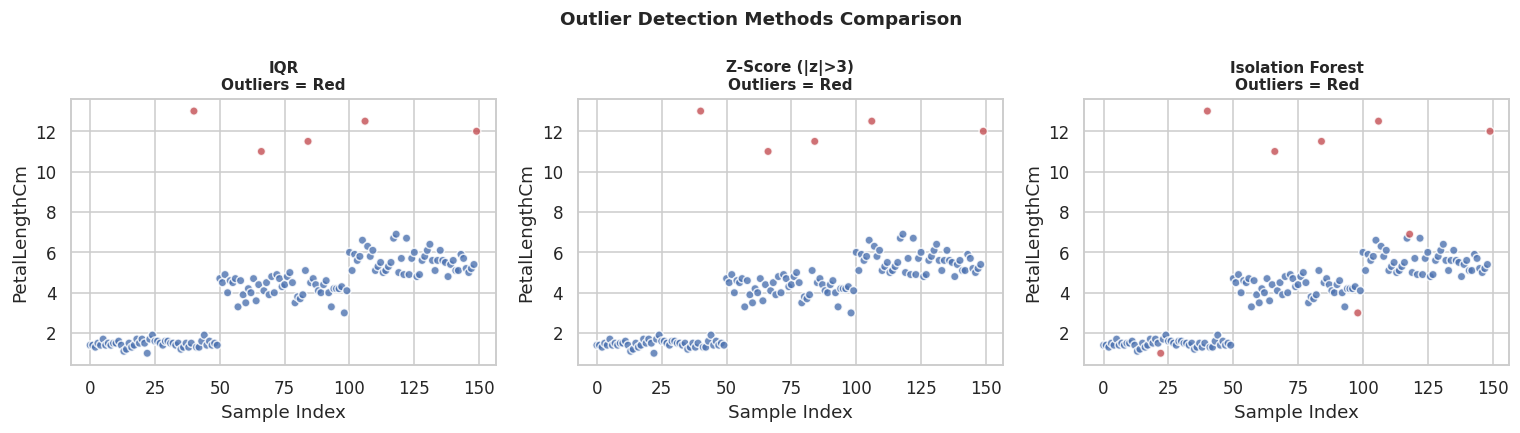

In [ ]:
# ── 4A: Detect outliers using IQR and Z-score ─────────────────────────────────
df_outlier = df[ORIGINAL_FEATURES].copy()

# Inject outliers for demonstration
np.random.seed(7)
out_idx = np.random.choice(df_outlier.index, size=5, replace=False)
df_outlier.loc[out_idx, 'PetalLengthCm'] = [12.0, 11.5, 13.0, 11.0, 12.5]

# IQR detection
Q1   = df_outlier['PetalLengthCm'].quantile(0.25)
Q3   = df_outlier['PetalLengthCm'].quantile(0.75)
IQR  = Q3 - Q1
lo   = Q1 - 1.5 * IQR
hi   = Q3 + 1.5 * IQR
iqr_mask = (df_outlier['PetalLengthCm'] < lo) | (df_outlier['PetalLengthCm'] > hi)

# Z-score detection
z    = np.abs(stats.zscore(df_outlier['PetalLengthCm']))
z_mask = z > 3

# Isolation Forest detection
from sklearn.ensemble import IsolationForest
iso  = IsolationForest(contamination=0.05, random_state=SEED)
iso_pred = iso.fit_predict(df_outlier[['PetalLengthCm']])
iso_mask = iso_pred == -1

print(f'IQR bounds: [{lo:.2f}, {hi:.2f}]')
print(f'Outliers — IQR: {iqr_mask.sum()} | Z-score: {z_mask.sum()} | IsoForest: {iso_mask.sum()}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels_m  = [('IQR', iqr_mask), ('Z-Score (|z|>3)', z_mask), ('Isolation Forest', iso_mask)]

for ax, (title, mask) in zip(axes, labels_m):
    ax.scatter(range(len(df_outlier)),
               df_outlier['PetalLengthCm'],
               c=['#C44E52' if m else '#4C72B0' for m in mask],
               s=30, alpha=0.8, edgecolor='white')
    ax.set_title(f'{title}\nOutliers = Red', fontweight='bold', fontsize=10)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('PetalLengthCm')

plt.suptitle('Outlier Detection Methods Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 4B: Winsorization vs Removal ──────────────────────────────────────────────
df_capped  = df_outlier.copy()
df_capped['PetalLengthCm'] = df_capped['PetalLengthCm'].clip(lo, hi)

df_removed = df_outlier[~iqr_mask].copy()

print(f'Original rows : {len(df_outlier)}')
print(f'After removal : {len(df_removed)}  (lost {len(df_outlier)-len(df_removed)} rows)')
print(f'After capping : {len(df_capped)}   (no rows lost)')
print(f'\nMax PetalLength — original: {df_outlier["PetalLengthCm"].max()}')
print(f'Max PetalLength — capped  : {df_capped["PetalLengthCm"].max():.2f}')

Original rows : 150
After removal : 145  (lost 5 rows)
After capping : 150   (no rows lost)

Max PetalLength — original: 13.0
Max PetalLength — capped  : 10.60


In [ ]:
# ── 5A: Create imbalanced Iris ────────────────────────────────────────────────
np.random.seed(SEED)
df_setosa   = df[df[TARGET] == 'setosa']
df_versic   = df[df[TARGET] == 'versicolor'].sample(35, random_state=SEED)
df_virgin   = df[df[TARGET] == 'virginica'].sample(15, random_state=SEED)
df_imb      = pd.concat([df_setosa, df_versic, df_virgin]).reset_index(drop=True)

X_imb = df_imb[ORIGINAL_FEATURES].values
y_imb = le.transform(df_imb[TARGET])

counts = pd.Series(y_imb).map({0:'setosa', 1:'versicolor', 2:'virginica'}).value_counts()
print('Imbalanced distribution:', dict(counts))

# Split
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    X_imb, y_imb, test_size=0.25, stratify=y_imb, random_state=SEED)

sc_imb = StandardScaler()
Xi_tr_sc = sc_imb.fit_transform(Xi_tr)
Xi_te_sc = sc_imb.transform(Xi_te)

Imbalanced distribution: {'setosa': np.int64(50), 'versicolor': np.int64(35), 'virginica': np.int64(15)}


In [ ]:
# ── 5B: Strategy comparison ───────────────────────────────────────────────────
strategies = {}

# 1. No correction
m1 = LogisticRegression(multi_class='multinomial', max_iter=500, random_state=SEED)
m1.fit(Xi_tr_sc, yi_tr)
strategies['No Correction'] = m1.predict(Xi_te_sc)

# 2. class_weight='balanced'
m2 = LogisticRegression(multi_class='multinomial', max_iter=500,
                         class_weight='balanced', random_state=SEED)
m2.fit(Xi_tr_sc, yi_tr)
strategies['class_weight balanced'] = m2.predict(Xi_te_sc)

# 3. Oversampling (manual resample)
Xi_tr_df = pd.DataFrame(Xi_tr_sc, columns=ORIGINAL_FEATURES)
Xi_tr_df['label'] = yi_tr
max_n = Xi_tr_df['label'].value_counts().max()
parts = [resample(Xi_tr_df[Xi_tr_df['label']==c],
                  n_samples=max_n, replace=True, random_state=SEED)
         for c in Xi_tr_df['label'].unique()]
df_over = pd.concat(parts)
m3 = LogisticRegression(multi_class='multinomial', max_iter=500, random_state=SEED)
m3.fit(df_over[ORIGINAL_FEATURES], df_over['label'])
strategies['Oversampling'] = m3.predict(Xi_te_sc)

# 4. Undersampling
min_n = Xi_tr_df['label'].value_counts().min()
uparts = [resample(Xi_tr_df[Xi_tr_df['label']==c],
                   n_samples=min_n, replace=False, random_state=SEED)
          for c in Xi_tr_df['label'].unique()]
df_under = pd.concat(uparts)
m4 = LogisticRegression(multi_class='multinomial', max_iter=500, random_state=SEED)
m4.fit(df_under[ORIGINAL_FEATURES], df_under['label'])
strategies['Undersampling'] = m4.predict(Xi_te_sc)

# Print metrics
print(f'{"Strategy":28s} {"Accuracy":>10} {"Macro-F1":>10} {"Virginica-Recall":>18}')
print('-' * 70)
for name, preds in strategies.items():
    acc  = accuracy_score(yi_te, preds)
    mf1  = f1_score(yi_te, preds, average='macro')
    vir_rec = (preds[yi_te == 2] == 2).sum() / (yi_te == 2).sum() if (yi_te == 2).sum() > 0 else 0
    print(f'{name:28s} {acc:>10.4f} {mf1:>10.4f} {vir_rec:>18.4f}')

Strategy                       Accuracy   Macro-F1   Virginica-Recall
----------------------------------------------------------------------
No Correction                    1.0000     1.0000             1.0000
class_weight balanced            0.9600     0.9434             1.0000
Oversampling                     0.9600     0.9434             1.0000
Undersampling                    0.9600     0.9434             1.0000


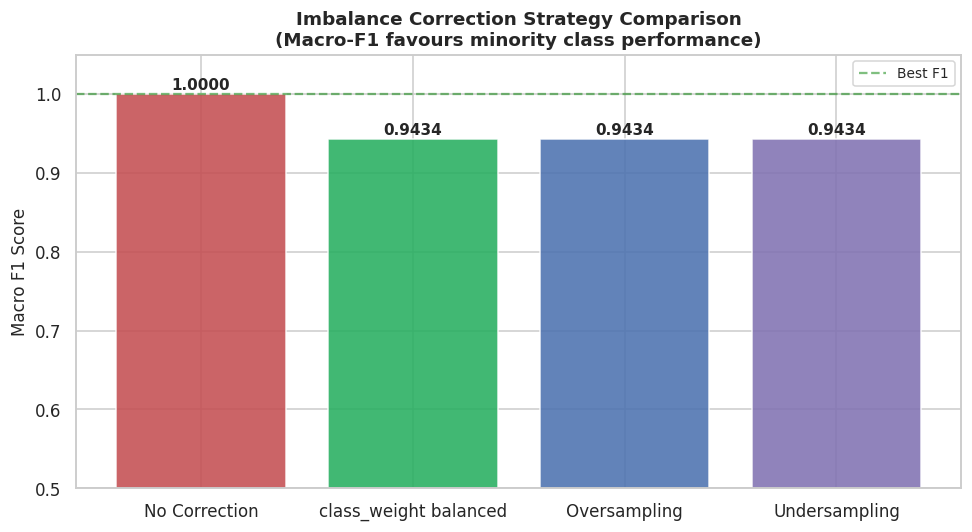

In [ ]:
# ── 5C: Visualise Macro-F1 comparison ────────────────────────────────────────
strategy_names = list(strategies.keys())
f1_scores_imb  = [f1_score(yi_te, preds, average='macro')
                  for preds in strategies.values()]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#C44E52', '#27ae60', '#4C72B0', '#8172B2']
bars = ax.bar(strategy_names, f1_scores_imb, color=bar_colors, edgecolor='white', alpha=0.88)
ax.set_ylim(0.5, 1.05)
ax.axhline(y=max(f1_scores_imb), color='green', linestyle='--', alpha=0.5, label='Best F1')
ax.set_ylabel('Macro F1 Score', fontsize=11)
ax.set_title('Imbalance Correction Strategy Comparison\n(Macro-F1 favours minority class performance)',
             fontweight='bold')
for bar, v in zip(bars, f1_scores_imb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()

In [ ]:
# ── 6A: Demonstrate data leakage ─────────────────────────────────────────────
X_full = df[ORIGINAL_FEATURES]
y_full = df['label']

# ❌ LEAKY approach — scaler sees test data
sc_leaky = StandardScaler()
X_scaled_leaky = sc_leaky.fit_transform(X_full)           # <-- BUG: whole dataset!
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_scaled_leaky, y_full, test_size=0.25, random_state=SEED, stratify=y_full)

lr_leaky = LogisticRegression(max_iter=500, random_state=SEED)
lr_leaky.fit(Xl_tr, yl_tr)
acc_leaky = accuracy_score(yl_te, lr_leaky.predict(Xl_te))

# ✅ CORRECT approach — scaler only sees train data
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_full, y_full, test_size=0.25, random_state=SEED, stratify=y_full)
sc_correct = StandardScaler()
Xc_tr_sc = sc_correct.fit_transform(Xc_tr)                # <-- CORRECT
Xc_te_sc = sc_correct.transform(Xc_te)

lr_correct = LogisticRegression(max_iter=500, random_state=SEED)
lr_correct.fit(Xc_tr_sc, yc_tr)
acc_correct = accuracy_score(yc_te, lr_correct.predict(Xc_te_sc))

print('❌ Leaky approach accuracy   :', round(acc_leaky,  4))
print('✅ Correct approach accuracy :', round(acc_correct, 4))
print('\n⚠️  Even small leakage can cause over-optimistic evaluation')
print('   In production, this means your model underperforms expectations!')

❌ Leaky approach accuracy   : 0.9211
✅ Correct approach accuracy : 0.9211

⚠️  Even small leakage can cause over-optimistic evaluation
   In production, this means your model underperforms expectations!


In [ ]:
# ── 6B: Correct approach using Pipeline ───────────────────────────────────────
# Pipeline guarantees: fit_transform on train, transform on test — always!

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(multi_class='multinomial',
                                   max_iter=500, random_state=SEED))
])

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', probability=True, random_state=SEED))
])

# Fit on RAW X_train — pipeline handles scaling internally
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.25, stratify=y_full, random_state=SEED)

pipe_lr.fit(X_tr_raw, y_tr)
pipe_svm.fit(X_tr_raw, y_tr)

print('Pipeline Logistic Regression accuracy:', accuracy_score(y_te, pipe_lr.predict(X_te_raw)))
print('Pipeline SVM (RBF) accuracy          :', accuracy_score(y_te, pipe_svm.predict(X_te_raw)))

Pipeline Logistic Regression accuracy: 0.9210526315789473
Pipeline SVM (RBF) accuracy          : 0.9473684210526315


In [ ]:
# ── 6C: Feature Engineering inside a Pipeline ─────────────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin

class IrisFeatureEngineer(BaseEstimator, TransformerMixin):
    """Custom transformer that adds domain-specific features."""
    def fit(self, X, y=None):     return self   # nothing to learn
    def transform(self, X, y=None):
        X = np.array(X)                         # SepalL, SepalW, PetalL, PetalW
        petal_ratio  = X[:, 2] / (X[:, 3] + 1e-6)
        sepal_ratio  = X[:, 0] / (X[:, 1] + 1e-6)
        petal_area   = np.pi * X[:, 2] * X[:, 3]
        total_size   = X.sum(axis=1)
        return np.column_stack([X, petal_ratio, sepal_ratio, petal_area, total_size])

pipe_fe = Pipeline([
    ('engineer', IrisFeatureEngineer()),      # Step 1: create features
    ('scaler',   StandardScaler()),           # Step 2: scale all features
    ('selector', SelectKBest(f_classif, k=6)),# Step 3: select top-6 features
    ('model',    LogisticRegression(multi_class='multinomial',
                                     max_iter=500, random_state=SEED))
])

pipe_fe.fit(X_tr_raw, y_tr)
acc_fe = accuracy_score(y_te, pipe_fe.predict(X_te_raw))
print(f'Pipeline with Feature Engineering accuracy: {acc_fe:.4f}')

# Cross-validate with the full pipeline — no leakage possible!
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_fe = cross_val_score(pipe_fe, X_full, y_full, cv=skf, scoring='accuracy')
print(f'5-Fold CV: {cv_fe.mean():.4f} ± {cv_fe.std():.4f}')

Pipeline with Feature Engineering accuracy: 0.9211
5-Fold CV: 0.9533 ± 0.0452


In [ ]:
# ── 6D: Pipeline with GridSearchCV — tune hyperparameters safely ───────────────
# Note the naming convention: step_name__param_name
param_grid = {
    'model__C':             [0.01, 0.1, 1, 10, 100],
    'model__multi_class':   ['multinomial'],
}

grid_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=500, random_state=SEED))
])

grid_search = GridSearchCV(grid_pipe, param_grid, cv=skf,
                            scoring='accuracy', n_jobs=-1, refit=True)
grid_search.fit(X_tr_raw, y_tr)

print('Best parameters found by GridSearchCV:')
print(' ', grid_search.best_params_)
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')
print(f'Test accuracy   : {accuracy_score(y_te, grid_search.predict(X_te_raw)):.4f}')

Best parameters found by GridSearchCV:
  {'model__C': 1, 'model__multi_class': 'multinomial'}
Best CV accuracy: 0.9648
Test accuracy   : 0.9211


In [ ]:
X_tr_sc,X_te_sc,y_tr,y_te=(
    Xc_tr_sc,Xc_te_sc,yc_tr,yc_te)
X_tr_raw_=Xc_tr.values
X_te_raw_=Xc_te.values

dt_full=DecisionTreeClassifier(random_state=SEED)
dt_full.fit(X_tr_sc,y_tr)

dt_pruned=DecisionTreeClassifier(max_depth=3,random_state=SPEED)
dt_pruned.fit(X_tr_sc,y_tr)

print('Decision Tree (full depth):')

)

SyntaxError: unmatched ')' (2160945074.py, line 14)